In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importing all necessary libraries

In [5]:
#reading the data 
Dataset= pd.read_csv("Diwali Sales Data.csv", encoding ='latin1')

In [6]:
#loading the table to see the columns and rows
Dataset.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [7]:
# To understand all the information about the dataset
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [8]:
# Analysing the above information, Columns 13 (Status) and 14 (unnamed1) has no data in it
# There are 12 cell with NaN in the column 12 (Amount)

In [9]:
#Number of rows and columns in the table
Dataset.shape

(11251, 15)

In [10]:
#number cells in the table
Dataset.size

168765

In [11]:
# finding number of cells without data
Dataset.isna().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [12]:
mask= Dataset.isna()
mask.tail()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
11247,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
11248,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
11249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
11250,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [13]:
mask = mask.any(axis=1)
mask.head()

0    True
1    True
2    True
3    True
4    True
dtype: bool

In [14]:
missing_rows= Dataset[mask]
missing_rows.size

168765

In [15]:
# Store the total number of values in a variable called `count_total`

count_total = Dataset.size
count_total

168765

In [16]:
# Drop the columns containing missing values, determine the number of remaining values



Dataset_cleaned = Dataset.drop(['Status', 'unnamed1'], axis=1)
Dataset_cleaned.head(5)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [17]:
Dataset_cleaned.isna().sum()
#finding number of empty cells

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [18]:
#removing empty rows
Dataset_cleaned = Dataset_cleaned.dropna(how='any')
Dataset_cleaned.shape

(11239, 13)

In [19]:
Dataset_cleaned.isna().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [20]:
Dataset_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In [21]:
Dataset_cleaned.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [22]:
# Changing Column 'mount' to integer
Dataset_cleaned["Amount"]=Dataset_cleaned["Amount"].astype(int)
Dataset_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11239 non-null  int64 
 1   Cust_name         11239 non-null  object
 2   Product_ID        11239 non-null  object
 3   Gender            11239 non-null  object
 4   Age Group         11239 non-null  object
 5   Age               11239 non-null  int64 
 6   Marital_Status    11239 non-null  int64 
 7   State             11239 non-null  object
 8   Zone              11239 non-null  object
 9   Occupation        11239 non-null  object
 10  Product_Category  11239 non-null  object
 11  Orders            11239 non-null  int64 
 12  Amount            11239 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


In [23]:
Dataset_cleaned.duplicated().sum()

np.int64(8)

In [24]:
Dataset_cleaned.drop_duplicates()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [25]:
# Dataset is cleaned and ready for futher analysis

In [26]:
# Finding revenue per customer
cust_sales = Dataset_cleaned.groupby('User_ID')['Amount'].sum()
print(cust_sales)

User_ID
1000001      3977
1000002      7098
1000003     23714
1000004     30381
1000005     27667
            ...  
1006035     28235
1006036    158407
1006037     22649
1006039     15061
1006040     61676
Name: Amount, Length: 3752, dtype: int64


In [27]:
# Adding a new column of Average order value
Dataset_cleaned['Avg_Order_Value'] = Dataset_cleaned['Amount'] / Dataset_cleaned['Orders']
Dataset_cleaned.head(5)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Avg_Order_Value
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952,23952.000000
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934,7978.000000
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924,7974.666667
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912,11956.000000
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877,11938.500000


<Axes: ylabel='Amount'>

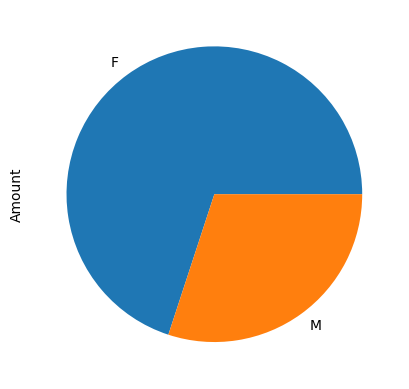

In [43]:
# Bar plot to understand gender wise contribution in sales
Dataset_cleaned.groupby("Gender")["Amount"].sum().plot(kind='pie')

In [29]:
# Insights: Females contributes more in sales than males

<Axes: xlabel='Age Group'>

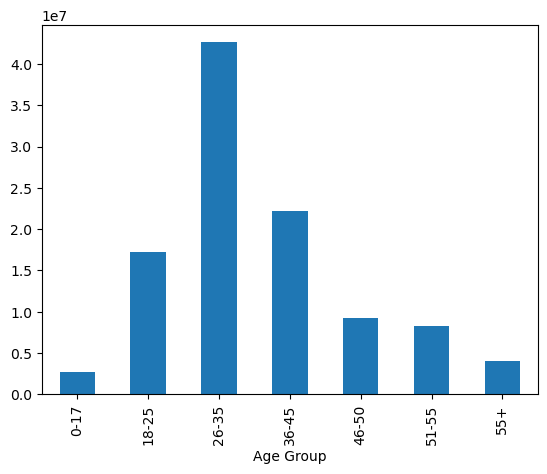

In [30]:
# Plotting the bar graph to understand which age group has the highes contribution in the sales 
Dataset_cleaned.groupby("Age Group")["Amount"].sum().plot(kind='bar')

In [31]:
# Age group of 26-35 has the highest contribution in sales followed by that is age group of 36-45 years

<Axes: xlabel='State'>

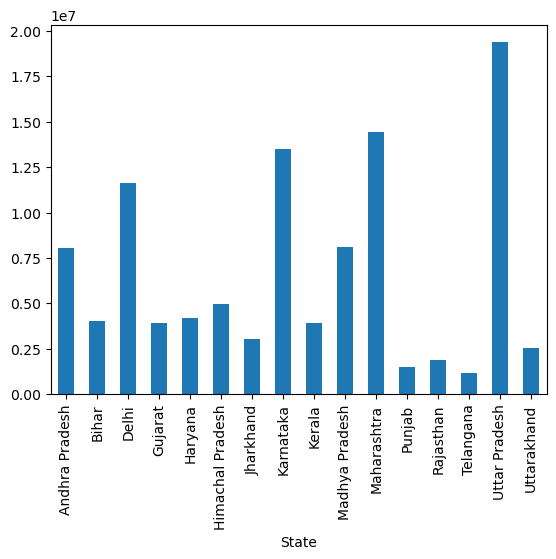

In [32]:
# Plotting the bar graph to understand which state has the highest sales
Dataset_cleaned.groupby("State")["Amount"].sum().plot(kind='bar')

In [33]:
# Highest contributing states are UP > Maharashtra > Karnataka > Delhi > MP > AP

In [34]:
Dataset_cleaned.groupby("State")["Amount"].sum().sort_values(ascending=False).head(9)

State
Uttar Pradesh       19374968
Maharashtra         14427543
Karnataka           13523540
Delhi               11603818
Madhya Pradesh       8101142
Andhra Pradesh       8037146
Himachal Pradesh     4963368
Haryana              4220175
Bihar                4022757
Name: Amount, dtype: int64

In [36]:
# To understand which occupation has the highest contribution in sales
Dataset_cleaned.groupby("Occupation")["Amount"].sum().sort_values(ascending=False).head(20)

Occupation
IT Sector          14755079
Healthcare         13034586
Aviation           12602298
Banking            10770610
Govt                8517212
Hospitality         6376405
Media               6295832
Automobile          5368596
Chemical            5297436
Lawyer              4981665
Retail              4783170
Food Processing     4070670
Construction        3597511
Textile             3204972
Agriculture         2593087
Name: Amount, dtype: int64

<Axes: xlabel='Occupation'>

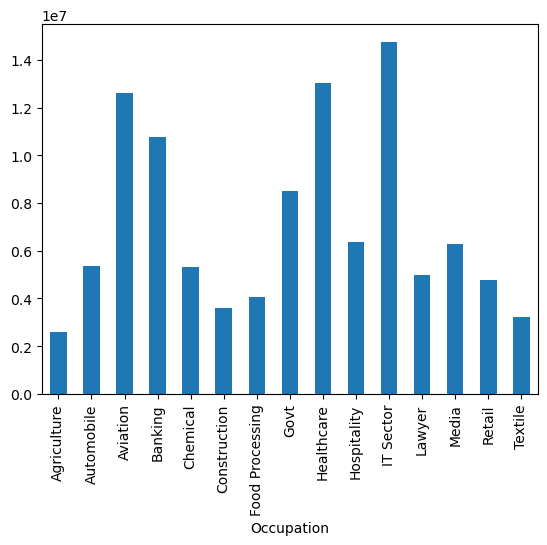

In [37]:
Dataset_cleaned.groupby("Occupation")["Amount"].sum().plot(kind='bar')

In [38]:
# To find out which product category is sold the most
Dataset_cleaned.groupby("Product_Category")["Amount"].sum().sort_values(ascending=False).head(20)

Product_Category
Food                     33933883
Clothing & Apparel       16495019
Electronics & Gadgets    15643846
Footwear & Shoes         15575209
Furniture                 5440051
Games & Toys              4331694
Sports Products           3635933
Beauty                    1959484
Auto                      1958609
Stationery                1676051
Household items           1569337
Tupperware                1155642
Books                     1061478
Decor                      730360
Pet Care                   482277
Hand & Power Tools         405618
Veterinary                 112702
Office                      81936
Name: Amount, dtype: int64

<Axes: xlabel='Product_Category'>

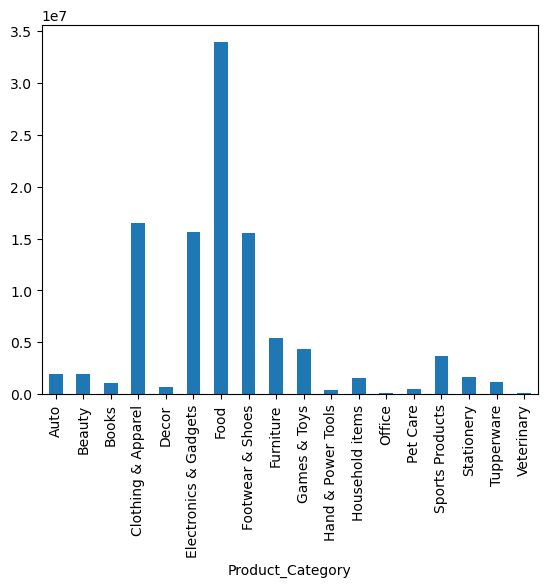

In [39]:
# Plotting the bar grapgh
Dataset_cleaned.groupby("Product_Category")["Amount"].sum().plot(kind='bar')

In [42]:
# downloading the cleaned dataset to be used in Tableau to create visuals
Dataset_cleaned.to_excel('Cleaned_dataset_Diwalisales.xlsx', index=False)
